# Общая информация о признаках

total_bill: этот атрибут представляет собой общую сумму счета, оплаченного клиентом, включая стоимость блюда, налоги и любые дополнительные сборы.

tip: этот атрибут обозначает сумму чаевых, оставленных клиентом. Обычно она рассчитывается как процент от общей суммы счета и часто является необязательной.

sex: этот атрибут указывает пол клиента. Это может быть как мужчина, так и женщина.

smoker: этот атрибут указывает, курит клиент или нет. Это категориальная переменная с двумя возможными значениями: «Да» для курильщиков и «Нет» для некурящих.

day: этот атрибут обозначает день недели, в который был съеден продукт. Это может быть любой из семи дней недели (например, понедельник, вторник и т. д.).

time: этот атрибут обозначает время суток, в которое был съеден продукт. Его часто делят на две категории: «обед» — для приемов пищи в течение дня и «ужин» — для приемов пищи вечером.

size: этот атрибут указывает на размер компании, обедающей вместе. Он обозначает количество человек, указанных в счете.

# 1. Загрузка и первичный осмотр

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv(r'tip.csv')

In [13]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [15]:
df.drop_duplicates(inplace=True)
df.shape

(243, 7)

### Удалили один дубликат. В данных не было пропусков


# 2. Feature Engineering

* #### Создадим новый признак tip_percent = tip / total_bill * 100 
* #### Округлим до 2-х знаков после запятой

In [16]:
df['tip_percent'] = round(df['tip'] / df['total_bill'] * 100, 2)
df['tip_percent']

0       5.94
1      16.05
2      16.66
3      13.98
4      14.68
       ...  
239    20.39
240     7.36
241     8.82
242     9.82
243    15.97
Name: tip_percent, Length: 243, dtype: float64

## Вопрос, как влияет на чаевые чек в процентом соотношении? Что влияет на это соотношение?

<Axes: xlabel='total_bill', ylabel='tip_percent'>

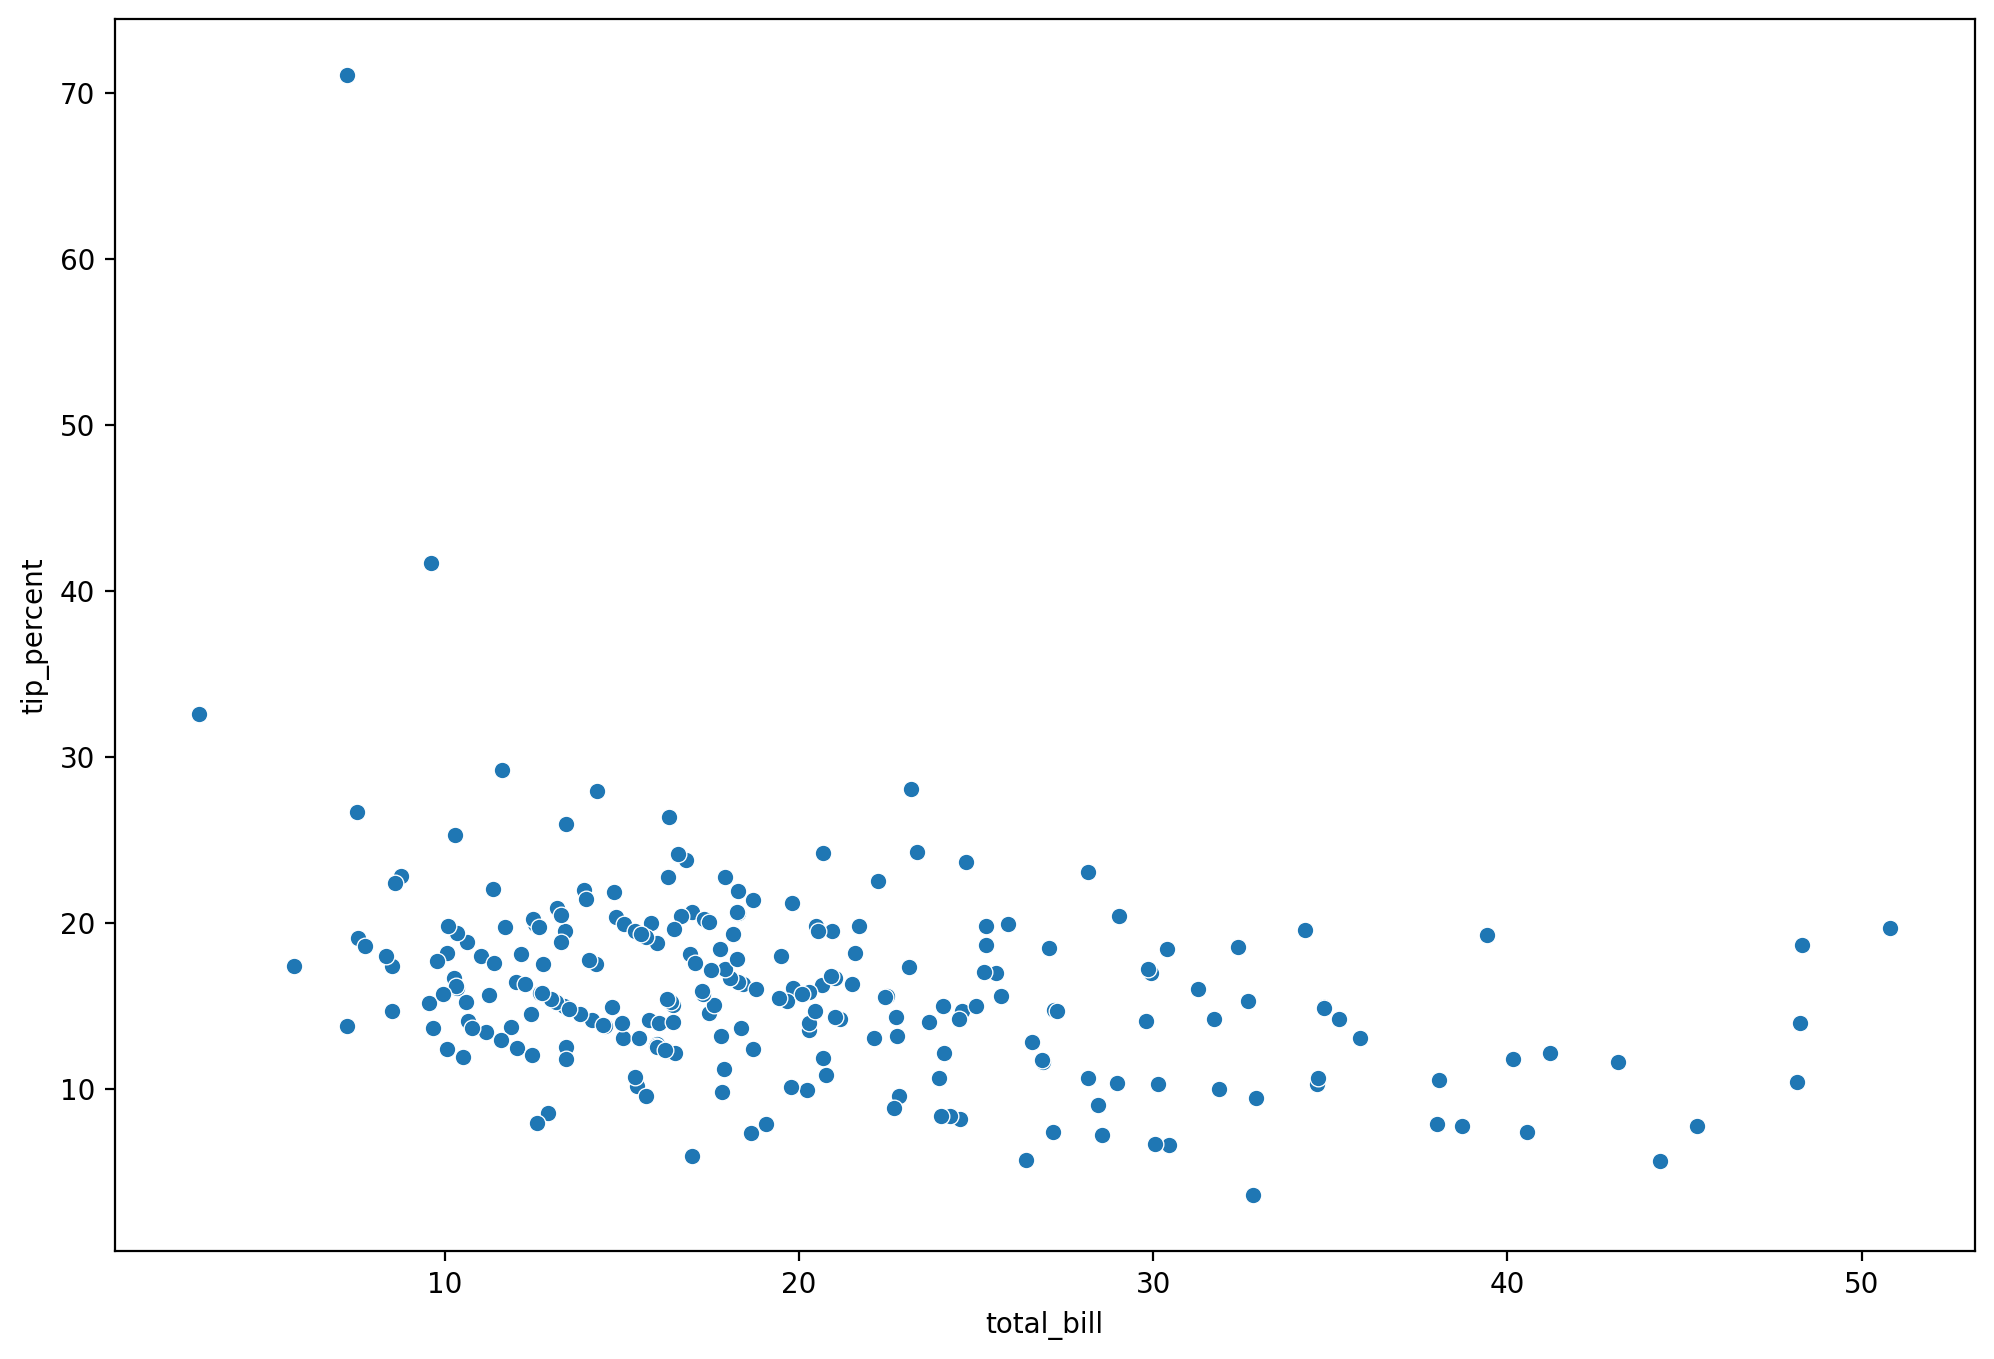

In [17]:
df_new = df.sort_values('total_bill')

fig, ax = plt.subplots(figsize=(12,8), dpi=200)
sns.scatterplot(data=df, x=df['total_bill'], y=df['tip_percent'])

### Мы видим, что можно примерно нарисовать прямую, которая проходит наилучшим образом через эти точки и эта прямая будет фунцией f(x) = 1/x, для всех x > 0

### То есть, с увелечением чека, процентная соотношение чаевых на чек уменьшается
* ##### Связано это с полом человека?
* ##### Связано это с временем приема пищи (утро, день, вечер)?
* ##### Cвязано ли это с количеством человек в компании?
* ##### Связано ли это c днем недели?

### Связано ли это с полом?

<Axes: xlabel='total_bill', ylabel='tip_percent'>

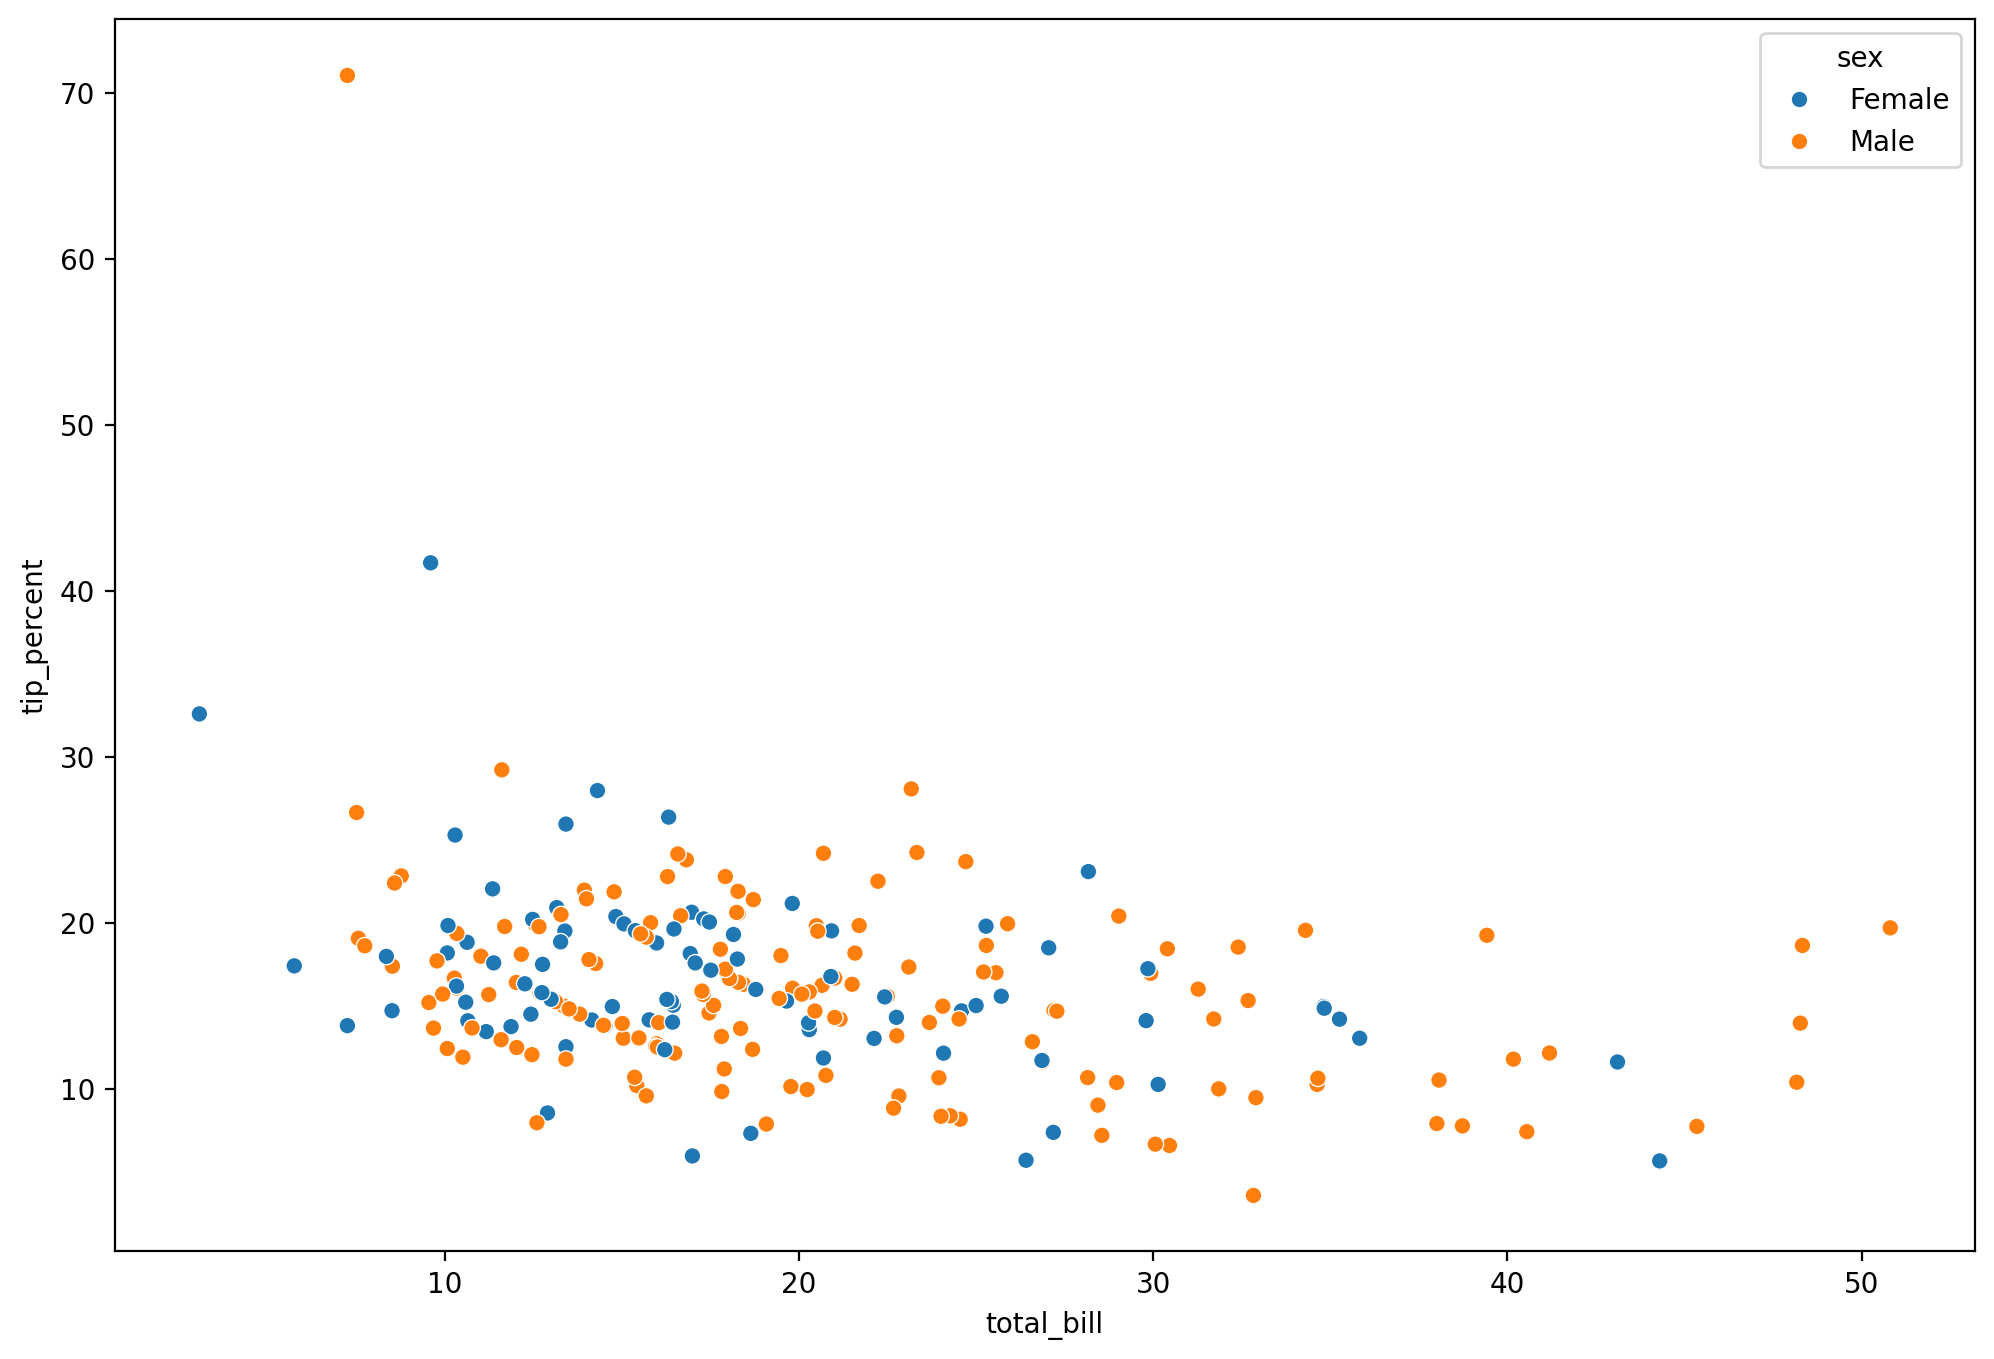

In [18]:
fig, ax = plt.subplots(figsize=(12,8), dpi=200)
sns.scatterplot(data=df, x=df['total_bill'], y=df['tip_percent'], hue='sex')

In [9]:
df_group_sex = df.groupby('sex').agg({'tip_percent':['mean', 'max', 'min']})
df_group_sex

tip_percent             
              mean    max   min
sex                            
Female   16.663023  41.67  5.64
Male     15.764713  71.03  3.56

### Видно, что мужчин больше чем девушек, поэтому, посмотрим соотношение девушек на мужчин, перед тем как делать вывод о процентом соотношении чаевых, которые могли бы зависеть от пола

In [10]:
df['sex'].value_counts()

sex
Male      157
Female     86
Name: count, dtype: int64

#### Мы видим, что мужчины в два раза больше посетили заведение, поэтому нельзя сказать о том, что мужчины оставляют больше чаевых и больше процентное соотношение. Это можно обьяснить тем, что мужчины платили больше только потому, что редко когда девушка платит за себя и за кого-то. Да и девушки редко когда ходят одни в заведение.

## Проверим, зависит ли это от времени, когда посещали заведение

<Axes: xlabel='total_bill', ylabel='tip_percent'>

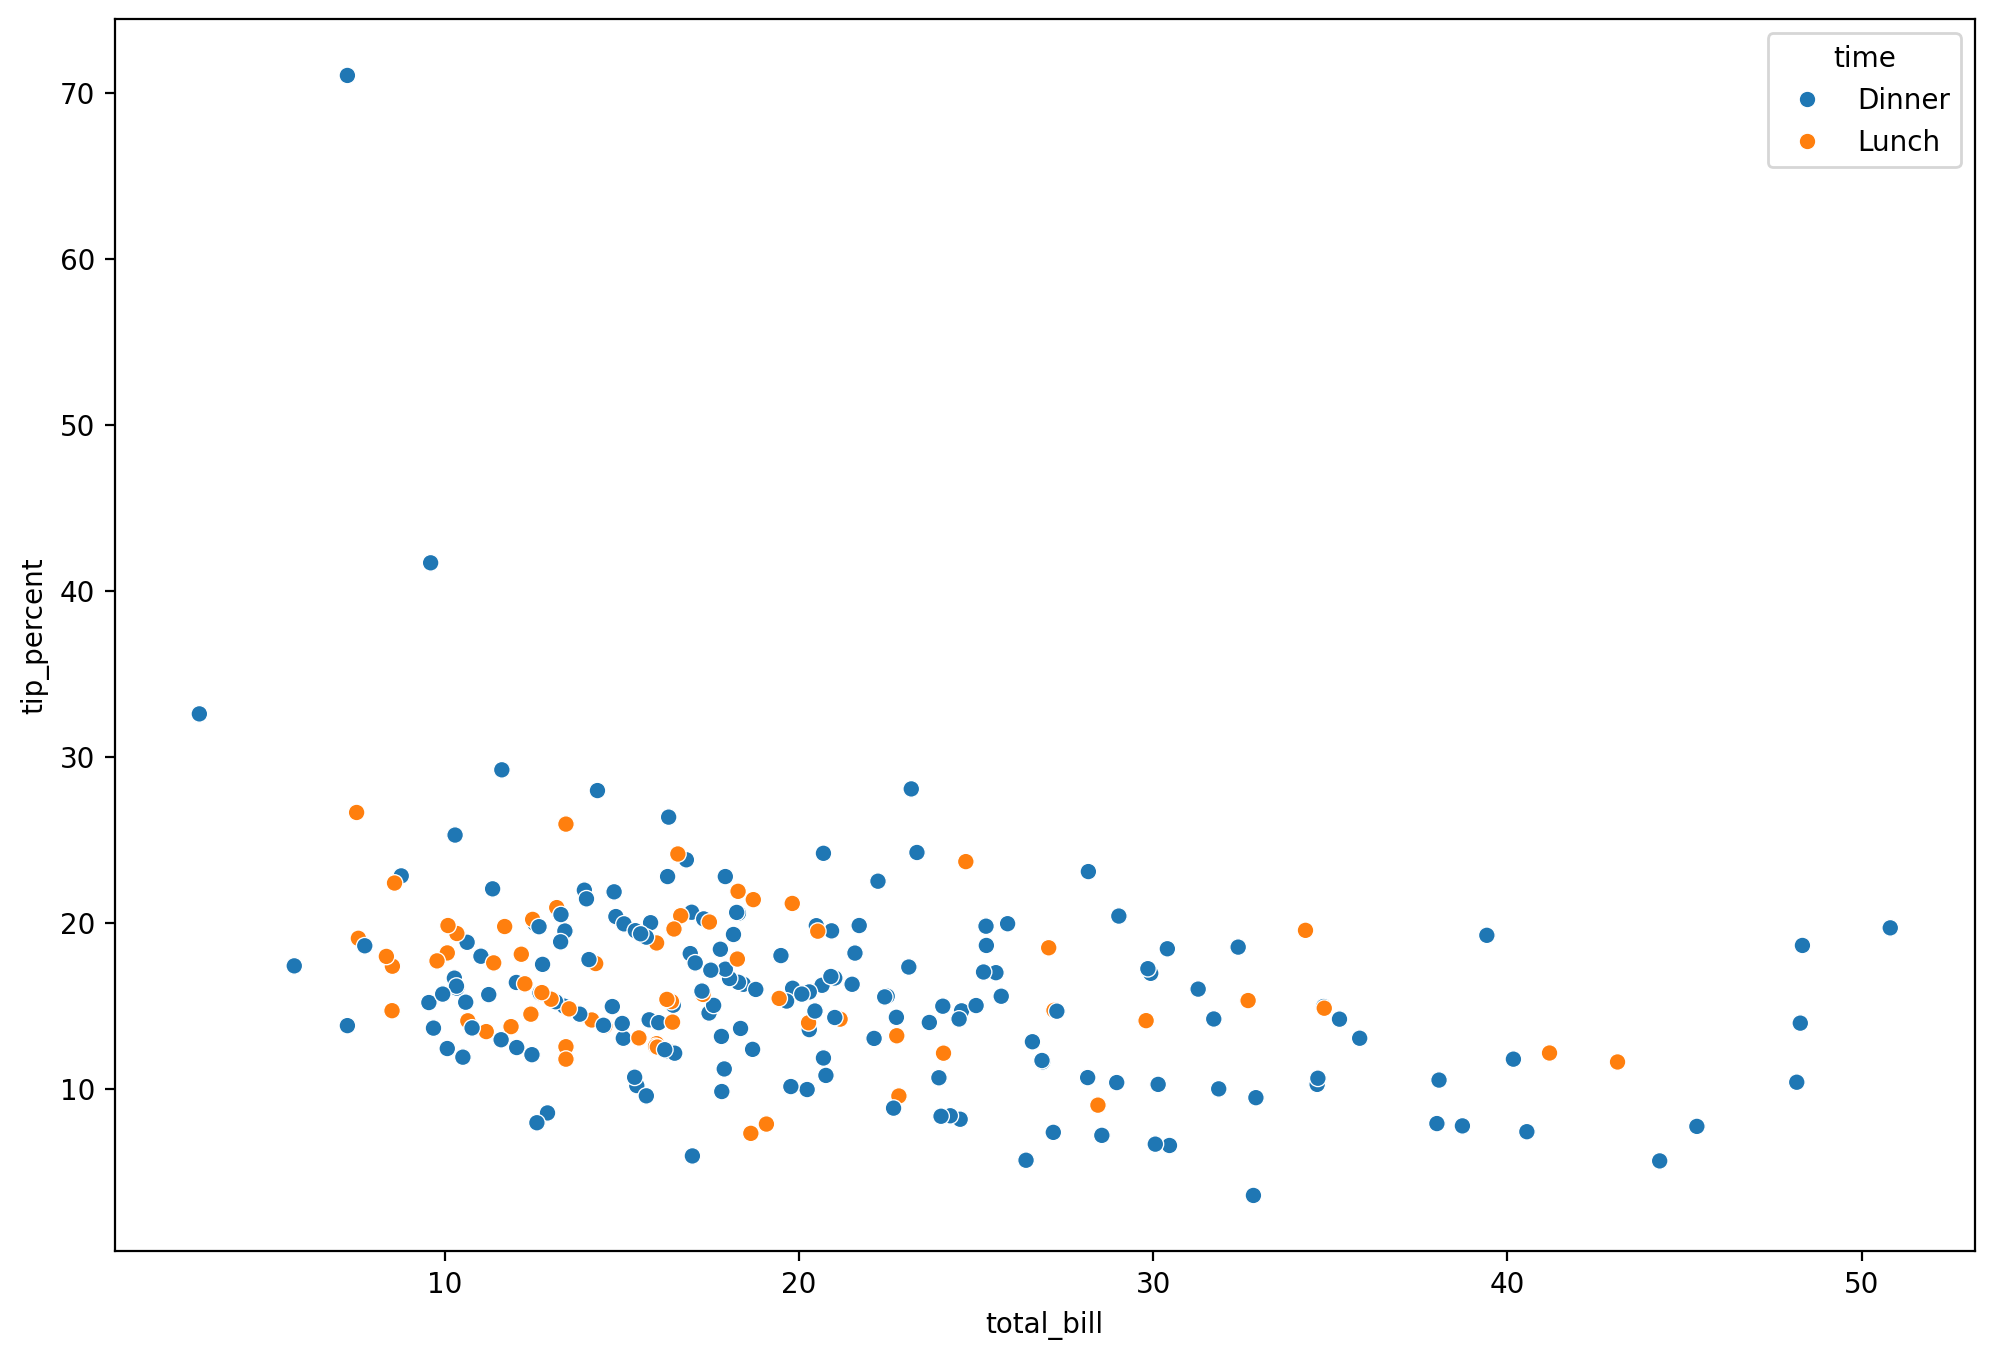

In [26]:
fig, ax = plt.subplots(figsize=(12,8), dpi=200)
sns.scatterplot(data=df, x=df['total_bill'], y=df['tip_percent'], hue='time')

In [27]:
df_group_sex = df.groupby('time').agg({'tip_percent':['mean', 'max', 'min']})
df_group_sex

tip_percent             
              mean    max   min
time                           
Dinner   15.951477  71.03  3.56
Lunch    16.427164  26.63  7.30

In [28]:
df['time'].value_counts()

time
Dinner    176
Lunch      67
Name: count, dtype: int64

#### Ужина больше, но процентное соотношение у обеда больше.

#### Посмотрим на процентное соотношение чаевых мужчин и женщин в разное время, в Dinner и Lunch

In [29]:
df_dinner = df[df['time'] == 'Dinner']
df_lunch  = df[~(df['time'] == 'Dinner')]

(67, 8)


In [32]:
df_dinner.groupby('sex').agg({
    'tip_percent':['mean', 'max', 'min', 'count', ]})

tip_percent                   
              mean    max   min count
sex                                  
Female   16.931731  41.67  5.64    52
Male     15.540403  71.03  3.56   124

In [33]:
df_lunch.groupby('sex').agg({
    'tip_percent':['mean', 'max', 'min', 'count', ]})

tip_percent                   
              mean    max   min count
sex                                  
Female   16.252059  25.93  7.30    34
Male     16.607576  26.63  7.86    33

### Связано ли это с количеством человек в компании???

In [36]:
df_day = df.groupby('day').agg({
    'tip_percent': ['mean', 'max', 'min', 'count']
})
df_day

tip_percent                    
            mean    max    min count
day                                 
Fri    16.991579  26.35  10.36    19
Sat    15.314598  32.57   3.56    87
Sun    16.689605  71.03   5.94    76
Thur   16.138689  26.63   7.30    61

- #### Можно предположить, что в пятницу многие ходят в заведение с коллегами и по рабочим отношениям, от того и чаевые в процентом соотношении больше. В то время как в субботу ходят уже семьёй. Также можно предположить, что из-за загруженной пятницы многие не желают идти заведение.

### Связано ли это c количеством человек в компании?

In [38]:
df_company = df.groupby('size').agg({
    'tip_percent' : ['mean', 'max', 'min', 'count']
})
df_company

tip_percent                    
            mean    max    min count
size                                
1      21.727500  32.57  13.79     4
2      16.579097  71.03   3.56   155
3      15.214737  23.07   5.64    38
4      14.594865  28.05   7.75    37
5      14.152000  24.17   6.57     5
6      15.620000  19.53  10.38     4

### Здесь мы видим, что размер компании больше всех показывает процентное соотношение чаевых от чека

# 3. Groupby — базовые агрегации
1. Сгруппирую данные по дню недели (day) и вычислю:

* средний total_bill,
* средний tip,
* средний tip_percent,
* количество записей.

2. Отсортирую результат по среднему tip_percent по убыванию

In [43]:
df_day = df.groupby('day').agg({
    'total_bill' : 'mean', 
    'tip' : 'mean', 
    'tip_percent' : 'mean',
    'size': 'count'})
df_day

,total_bill,tip,tip_percent,size
day,,,,
Fri,17.151579,2.734737,16.991579,19
Sat,20.441379,2.993103,15.314598,87
Sun,21.410000,3.255132,16.689605,76
Thur,17.759508,2.784098,16.138689,61


In [45]:
df_day.sort_values('tip_percent', ascending=False)

,total_bill,tip,tip_percent,size
day,,,,
Fri,17.151579,2.734737,16.991579,19
Sun,21.410000,3.255132,16.689605,76
Thur,17.759508,2.784098,16.138689,61
Sat,20.441379,2.993103,15.314598,87


# 4 Groupby — несколько признаков
* Посмотрим на то, в каждом ли дне люди приходили как на вечер, так и на обед

In [96]:
df_day_time = df.groupby(['day', 'time']).agg({'tip_percent': 'mean'})
display(df_day_time)
df_day_time.pivot_table(index='day', columns='time', values='tip_percent', fill_value=0).reset_index()

tip_percent
day  time               
Fri  Dinner    15.892500
     Lunch     18.875714
Sat  Dinner    15.314598
Sun  Dinner    16.689605
Thur Dinner    15.970000
     Lunch     16.141500

time,day,Dinner,Lunch
0,Fri,15.892500,18.875714
1,Sat,15.314598,0.000000
2,Sun,16.689605,0.000000
3,Thur,15.970000,16.141500


### В Субботу и воскресенье не было обеда

# 5. Pivot Table

* Построю pivot_table: по строкам — day, по столбцам — smoker, значения — средний tip

In [88]:
df.pivot_table(index='smoker', columns='day', values='tip')

day,Fri,Sat,Sun,Thur
smoker,,,,
No,2.8125,3.102889,3.167895,2.673778
Yes,2.7140,2.875476,3.516842,3.094375


#### Нельзя сказать точно, кто платил больше курящий или не курящий

# 6. Merge

* Создадим вручную DataFrame days_info с колонками :

* * day: ['Thur', 'Fri', 'Sat', 'Sun']
  * is_weekend: [False, False, True, True]


* Смерджу его с основным датасетом tips по колонке day (how='left')
* Сгруппирую по is_weekend и найду средний tip_percent.

In [65]:
dct = {
    'day' : ['Thur', 'Fri', 'Sat', 'Sun'],
    'is_weekend': [False, False, True, True]
}
days_info = pd.DataFrame(data=dct)
days_info

,day,is_weekend
0,Thur,False
1,Fri,False
2,Sat,True
3,Sun,True


In [83]:
df_merge = df.merge(days_info, how='left')
df_merge.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percent,is_weekend
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94,True
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05,True
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66,True
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98,True
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68,True


In [84]:
df_merge.groupby('is_weekend').agg({'tip_percent':'mean'})

,tip_percent
is_weekend,
False,16.341250
True,15.955706


## Это говорит нам о том, что в выходные чаевые относительно чека меньше.

# 7. Визуализация

* Построю barplot: средний total_bill в зависимости от size (размер компании).

* Построю гистограмму распределения tip_percent (укажи kde=True).

* Построю scatterplot: total_bill по оси X, tip по оси Y, с цветом по time и размером точки по size.

* Построй boxplot: распределение tip_percent по дням недели.

## Barplot

In [78]:
data = df.groupby('size').agg({'total_bill' : 'mean'})
data

,total_bill
size,
1,7.242500
2,16.470258
3,23.277632
4,28.613514
5,30.068000
6,34.830000


<Axes: xlabel='size', ylabel='total_bill'>

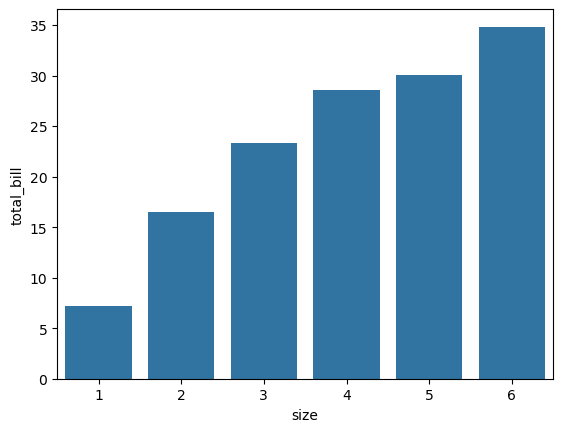

In [80]:
 sns.barplot(data=data, x='size', y='total_bill')

## Histplot

<Axes: xlabel='tip_percent', ylabel='Count'>

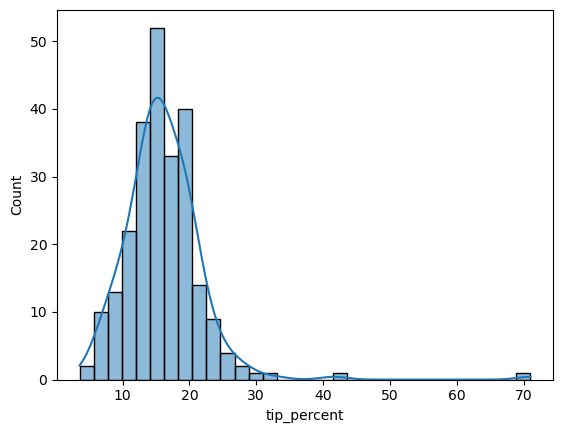

In [86]:
sns.histplot(data=df, x='tip_percent', kde=True)

# scatterplot

<Axes: xlabel='total_bill', ylabel='tip'>

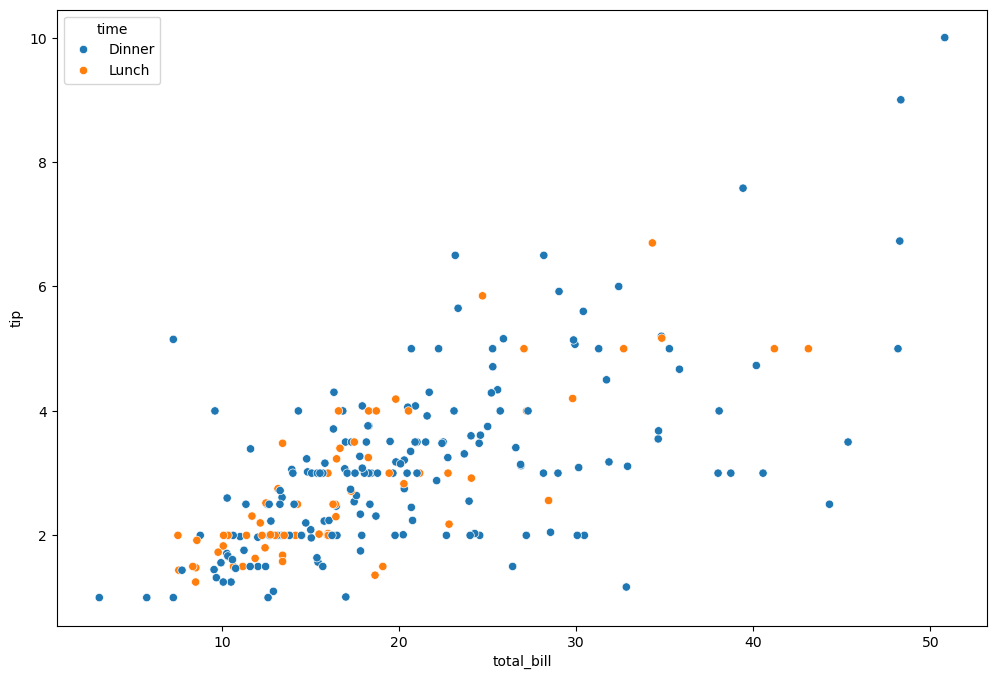

In [95]:
fig, ax = plt.subplots(figsize=(12,8))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time')

# Boxplot

,tip_percent
day,
Fri,16.991579
Sat,15.314598
Sun,16.689605
Thur,16.138689


<Axes: xlabel='tip_percent', ylabel='day'>

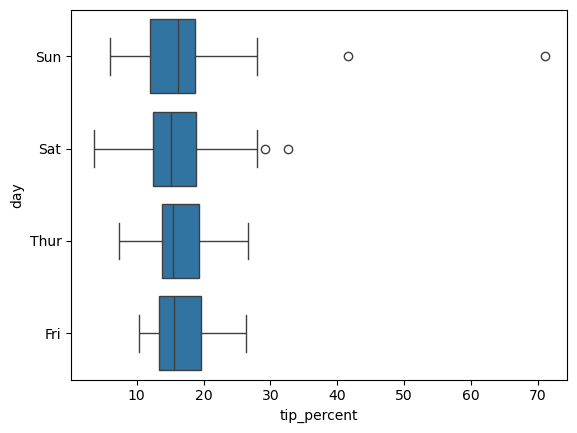

In [98]:
dff_b = df.groupby('day').agg({'tip_percent':'mean'})
display(dff_b)
sns.boxplot(data=df, x='tip_percent', y='day')

# 8. Аналитические выводы

* В какие дни оставляют больше чаевых (в процентах)?

* Влияет ли размер компании на средний чек и на процент чаевых?

* Есть ли разница между курящими и некурящими?

* В выходные чаевые выше, чем в будни?